# MLP Model

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
# with open('names.txt', 'r') as f:
#     names = f.readlines()

# []

In [2]:
names = open('names.txt', 'r').read().splitlines()
names

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [3]:
vocab = sorted(list(set(''.join(names))))

In [4]:
char2num = {c:i+1 for i, c in enumerate(vocab)}
char2num['.'] = 0
num2char = {i: c for c, i in char2num.items()}

In [5]:
char2num

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [6]:
for name in names[:3]:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

. e
e m
m m
m a
a .
. o
o l
l i
i v
v i
i a
a .
. a
a v
v a
a .


In [ ]:

# x      y

# .      e
# e      m
# m      m
# m      a
# a      .
# .      o
# o      l
# l      i
# i      v
# v      i
# i      a
# a      .
# .      a
# a      v
# v      a
# a      .

## Creating and prepping the training set

In [7]:
# create the training data xs, ys
xs, ys = [], []
for name in names[:1]:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = char2num[ch1]
        ix2 = char2num[ch2]
        xs.append(ix1)
        ys.append(ix2)

In [8]:
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [9]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [ ]:
xs # 5 training examples, each is a index representing a character

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys # 5 labels

tensor([ 5, 13, 13,  1,  0])

In [57]:
# we cannot feed raw indices into a NN, so we need to encode them somehow

### one-hot encoding the elemenets of the x tensor 

In [10]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # cast to float32 to feed into nn

In [11]:
xenc.shape 


# our dataset (for now) has 5 rows and 27 features
# 5 rows (training examples), 
# each row has 27 (the length of our vocab) binary switches 
# with one possible position with the value 1
# so we turn each char index into a one-hot vector

torch.Size([5, 27])

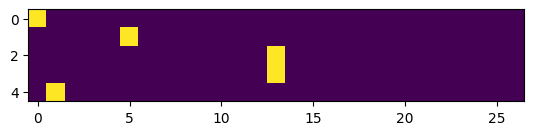

In [71]:
plt.imshow(xenc)

In [72]:
# one_hot does not change the dtype, so xenc is int64.
# when we feed xs into a NN we wanna make sure 
# that the values inside the tnesor are floats to make GD possible

In [14]:
xenc.dtype

torch.float32

### Building the first neuron

In [13]:
# shape of a weight matrix: (out_dim, in_dim) 
# -> (num neurons in current layer, num features or inputs from previous layer)

# in Andrej's code, he inits W in the transposed form for convenience
g = torch.Generator().manual_seed(2147483647)

W = torch.randn((1, 27), generator=g) 

# why 1, 27?
# the 1 is for the single neuron in the current layer
# and 27 is the number of features (one-hot encoded vectors) coming 
# in from th eprevious layer

In [15]:
W

tensor([[ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
          0.0791,  0.9046, -0.4713, -0.7389,  1.7249,  0.0380, -1.0694, -0.5374,
          0.0511,  1.3095, -0.8022,  1.1500, -0.9643, -0.8815, -0.8295, -0.2548,
         -0.9648, -0.2321, -0.3476]])

In [16]:
W.shape

torch.Size([1, 27])

In [ ]:
# import torch.nn as nn


# layer = nn.Linear(in_features=27, out_features=1)
# print(layer.weight.shape)

torch.Size([1, 27])


In [105]:
xenc[0, :]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
W.T

tensor([[ 1.5674],
        [-0.2373],
        [-0.0274],
        [-1.1008],
        [ 0.2859],
        [-0.0296],
        [-1.5471],
        [ 0.6049],
        [ 0.0791],
        [ 0.9046],
        [-0.4713],
        [-0.7389],
        [ 1.7249],
        [ 0.0380],
        [-1.0694],
        [-0.5374],
        [ 0.0511],
        [ 1.3095],
        [-0.8022],
        [ 1.1500],
        [-0.9643],
        [-0.8815],
        [-0.8295],
        [-0.2548],
        [-0.9648],
        [-0.2321],
        [-0.3476]])

In [18]:
torch.matmul(xenc[0, :], W.T) # (1, 27) @ (27, 1) = (1, 1)

tensor([1.5674])

In [19]:
# (5,27) @ (1, 27).T -> (5,1)
# (5,27) @ (27, 1) -> (5,1)
xenc @ W.T

# what are these logits (Zs) telling us?

tensor([[ 1.5674],
        [-0.0296],
        [ 0.0380],
        [ 0.0380],
        [-0.2373]])

In [20]:
# now I wanna add 27 neurons instead of 1, 
# so I can learn 27 different patterns in the data
W = torch.randn((27, 27), generator=g)

In [ ]:
logits = xenc @ W.T # logits = z or pre-activations
#       (5, 27) @ (27, 27) = (5, 27)

In [22]:
logits.shape

torch.Size([5, 27])

In [ ]:
logits[3, 13] 
# given the 4th training example, the logit for the 
# 14th neuron is -0.01, which is a measure of how much this neuron is 
# activated by this training example

tensor(-0.0102)

In [23]:
logits[0, 0]
# gives the firing rate of the first neuron when 
# looking at the first training example

tensor(-1.0549)

In [ ]:
xenc[0,:] # first row

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
W[:, 0] # first column

tensor([-1.0549,  1.5514, -0.2977,  0.4391,  1.7961,  1.8598, -0.5993, -0.2774,
         0.2446, -1.1707,  0.1130, -0.4154,  0.3857,  1.7206,  1.2605,  0.1106,
         0.3248, -0.1322,  0.7560, -0.8547,  2.0022,  0.8433, -0.2195, -0.1838,
         0.2460, -0.7528, -0.4551])

In [ ]:
(xenc[0,:] * W[:, 0]).sum() 
# this is the same as 
# torch.matmul(xenc[0, :], W[:, 0])

tensor(-1.0549)

#### interpreting what logits mean

In [24]:
logits = xenc @ W.T # logits = z or pre-activations
logits.shape

torch.Size([5, 27])

In [25]:
logits # log counts, not probabilities yet
# to get the counts, we need to .exp()

tensor([[-1.0549e+00,  1.5514e+00, -2.9771e-01,  4.3905e-01,  1.7961e+00,
          1.8598e+00, -5.9933e-01, -2.7737e-01,  2.4456e-01, -1.1707e+00,
          1.1298e-01, -4.1538e-01,  3.8572e-01,  1.7206e+00,  1.2605e+00,
          1.1056e-01,  3.2481e-01, -1.3223e-01,  7.5598e-01, -8.5465e-01,
          2.0022e+00,  8.4326e-01, -2.1952e-01, -1.8384e-01,  2.4599e-01,
         -7.5282e-01, -4.5507e-01],
        [ 5.4011e-02, -3.7170e-01, -1.1887e+00,  9.6838e-01,  7.5720e-01,
          2.0002e+00, -2.4780e-01,  6.4045e-01,  2.4687e-01, -8.0651e-01,
         -3.8843e-01,  1.8784e+00, -9.4188e-01,  4.5095e-02,  6.1047e-01,
          3.5374e-01, -7.0343e-01, -1.9482e+00,  9.8503e-02,  1.3969e-01,
         -1.4596e-01, -7.5789e-01,  6.1175e-01, -1.2756e-03,  1.1088e+00,
          8.5687e-01,  1.2561e+00],
        [ 3.8012e-01, -3.0560e-01,  2.0722e-01,  3.1748e-01, -5.5840e-02,
         -2.1448e-01,  1.2348e+00,  5.2054e-01,  8.1827e-01, -6.3099e-01,
         -1.4107e+00,  6.3393e-01, -9.53

In [26]:
logits = xenc @ W.T # forward pass - y_hat
counts = logits.exp() # equivalent to the N matrix of counts from the bigram nb

# probs is counts normalized by row, so that they sum to 1
probs = counts / counts.sum(1, keepdim=True) # equivalent to the P matrix of probabilities from the bigram nb

In [29]:
counts[0,:]

tensor([0.3482, 4.7180, 0.7425, 1.5512, 6.0262, 6.4226, 0.5492, 0.7578, 1.2771,
        0.3101, 1.1196, 0.6601, 1.4707, 5.5880, 3.5272, 1.1169, 1.3838, 0.8761,
        2.1297, 0.4254, 7.4051, 2.3239, 0.8029, 0.8321, 1.2789, 0.4710, 0.6344])

In [30]:
counts.sum(1, keepdim=True) # row totals

tensor([[54.7489],
        [46.4973],
        [35.0494],
        [35.0494],
        [36.4955]])

In [ ]:
# 5,  27
# 5,   1 # div is broadcastable
# 5,  27 # probs has the same shape as counts, but each row sums to 1

In [31]:
probs.shape

torch.Size([5, 27])

In [32]:
probs.sum(1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [134]:
probs[0, :]

tensor([0.0064, 0.0862, 0.0136, 0.0283, 0.1101, 0.1173, 0.0100, 0.0138, 0.0233,
        0.0057, 0.0204, 0.0121, 0.0269, 0.1021, 0.0644, 0.0204, 0.0253, 0.0160,
        0.0389, 0.0078, 0.1353, 0.0424, 0.0147, 0.0152, 0.0234, 0.0086, 0.0116])

In [142]:
probs[2]

tensor([0.0417, 0.0210, 0.0351, 0.0392, 0.0270, 0.0230, 0.0981, 0.0480, 0.0647,
        0.0152, 0.0070, 0.0538, 0.0259, 0.0282, 0.0295, 0.0341, 0.0219, 0.0361,
        0.0505, 0.0029, 0.0045, 0.1123, 0.0205, 0.0975, 0.0133, 0.0331, 0.0162])

In [148]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print('----------------------')
    print()
    print(f"bigram example {i+1}: {num2char[x]} {num2char[y]}")
    print()
    print(f"input to the NN: {x}")
    print()
    print(f"Output probabilities from the neural net:\n {probs[i]}")
    print()
    print('label (actual next character):', y)
    print()
    p = probs[i, y]
    print()
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    nll = -logp
    nlls[i] = nll
    
print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------------------

bigram example 1: . e

input to the NN: 0

Output probabilities from the neural net:
 tensor([0.0064, 0.0862, 0.0136, 0.0283, 0.1101, 0.1173, 0.0100, 0.0138, 0.0233,
        0.0057, 0.0204, 0.0121, 0.0269, 0.1021, 0.0644, 0.0204, 0.0253, 0.0160,
        0.0389, 0.0078, 0.1353, 0.0424, 0.0147, 0.0152, 0.0234, 0.0086, 0.0116])

label (actual next character): 5


probability assigned by the net to the the correct character: 0.11731091886758804
----------------------

bigram example 2: e m

input to the NN: 5

Output probabilities from the neural net:
 tensor([0.0227, 0.0148, 0.0066, 0.0566, 0.0459, 0.1589, 0.0168, 0.0408, 0.0275,
        0.0096, 0.0146, 0.1407, 0.0084, 0.0225, 0.0396, 0.0306, 0.0106, 0.0031,
        0.0237, 0.0247, 0.0186, 0.0101, 0.0397, 0.0215, 0.0652, 0.0507, 0.0755])

label (actual next character): 13


probability assigned by the net to the the correct character: 0.022498654201626778
----------------------

bigram example 3: m m

input to the 

In [ ]:
# nlls = torch.zeros(5)
# for i in range(5):
#     # i-th bigram:
#     x = xs[i].item() # input character index
#     y = ys[i].item() # label character index
#     print('--------')
#     print(f'bigram example {i+1}: {num2char[x]}{num2char[y]} (indexes {x},{y})')
#     print('input to the neural net:', x)
#     print('output probabilities from the neural net:', probs[i])
#     print('label (actual next character):', y)
#     p = probs[i, y]
#     print('probability assigned by the net to the the correct character:', p.item())
#     logp = torch.log(p)
#     print('log likelihood:', logp.item())
#     nll = -logp
#     print('negative log likelihood:', nll.item())
#     nlls[i] = nll

# print('=========')
# print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0064, 0.0862, 0.0136, 0.0283, 0.1101, 0.1173, 0.0100, 0.0138, 0.0233,
        0.0057, 0.0204, 0.0121, 0.0269, 0.1021, 0.0644, 0.0204, 0.0253, 0.0160,
        0.0389, 0.0078, 0.1353, 0.0424, 0.0147, 0.0152, 0.0234, 0.0086, 0.0116])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.11731091886758804
log likelihood: -2.142927408218384
negative log likelihood: 2.142927408218384
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0227, 0.0148, 0.0066, 0.0566, 0.0459, 0.1589, 0.0168, 0.0408, 0.0275,
        0.0096, 0.0146, 0.1407, 0.0084, 0.0225, 0.0396, 0.0306, 0.0106, 0.0031,
        0.0237, 0.0247, 0.0186, 0.0101, 0.0397, 0.0215, 0.0652, 0.0507, 0.0755])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

## Training the NN

In [ ]:
# forward pass
# loss
# zero gradients p.grad = None or 0
# loss.backward()
# update weights (p.data) with GD 

In [33]:
print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [34]:
probs

tensor([[0.0064, 0.0862, 0.0136, 0.0283, 0.1101, 0.1173, 0.0100, 0.0138, 0.0233,
         0.0057, 0.0204, 0.0121, 0.0269, 0.1021, 0.0644, 0.0204, 0.0253, 0.0160,
         0.0389, 0.0078, 0.1353, 0.0424, 0.0147, 0.0152, 0.0234, 0.0086, 0.0116],
        [0.0227, 0.0148, 0.0066, 0.0566, 0.0459, 0.1589, 0.0168, 0.0408, 0.0275,
         0.0096, 0.0146, 0.1407, 0.0084, 0.0225, 0.0396, 0.0306, 0.0106, 0.0031,
         0.0237, 0.0247, 0.0186, 0.0101, 0.0397, 0.0215, 0.0652, 0.0507, 0.0755],
        [0.0417, 0.0210, 0.0351, 0.0392, 0.0270, 0.0230, 0.0981, 0.0480, 0.0647,
         0.0152, 0.0070, 0.0538, 0.0259, 0.0282, 0.0295, 0.0341, 0.0219, 0.0361,
         0.0505, 0.0029, 0.0045, 0.1123, 0.0205, 0.0975, 0.0133, 0.0331, 0.0162],
        [0.0417, 0.0210, 0.0351, 0.0392, 0.0270, 0.0230, 0.0981, 0.0480, 0.0647,
         0.0152, 0.0070, 0.0538, 0.0259, 0.0282, 0.0295, 0.0341, 0.0219, 0.0361,
         0.0505, 0.0029, 0.0045, 0.1123, 0.0205, 0.0975, 0.0133, 0.0331, 0.0162],
        [0.0633, 0.0072,

In [ ]:
# the trick is that our y_hat is the probs
# so we wanna pluck out the appropriate probs 
# based on the input data and labels, 
# and then compute the loss based on those plucked out probabilities



# manual way of extracting probs
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.1173),
 tensor(0.0225),
 tensor(0.0282),
 tensor(0.0210),
 tensor(0.0633))

In [35]:
probs[torch.arange(5), ys]

tensor([0.1173, 0.0225, 0.0282, 0.0210, 0.0633])

In [36]:
# now we wanna use thes probs to calcualle the loss
loss = -probs[torch.arange(5), ys].log().mean() # negative mean log liklihood
loss

tensor(3.2253)

## ---------- Optimization --------------------

In [153]:
# create the training data xs, ys
xs, ys = [], []
for name in names[:5]:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = char2num[ch1]
        ix2 = char2num[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.numel()
print(f'number of training examples: {num}')

number of training examples: 32


In [154]:
W = torch.randn((27, 27), requires_grad=True)

In [ ]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W.T
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(xs)), ys].log().mean() # mean nll

In [ ]:
# backward pass
W.grad = None
loss.backward()

# update params
W.data += - 0.1 * W.grad

## Training Loop

In [37]:
# create the training data xs, ys
xs, ys = [], []
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = char2num[ch1]
        ix2 = char2num[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.numel()
print(f'number of training examples: {num}')

number of training examples: 228146


In [38]:
W = torch.randn((27, 27), requires_grad=True, generator=g)

In [ ]:
epochs = 1000
for k in range(epochs):
    # encode indices into binary 0,1 
    xenc = F.one_hot(xs, num_classes=27).float()
    # forward pass
    logits = xenc @ W.T # log counts
    counts = logits.exp() # same as N from the naive bigram model
    # normalize counts
    probs = counts / counts.sum(1, keepdim=True)
    
    #  compute the loss
    loss = -probs[torch.arange(len(xs)), ys].log().mean() # mean nll
    
    if (k+1) % 100 == 0:
        print(f"Epoch {k+1}/{epochs}, loss: {loss.item():.4f}")
    
    # zero gradients before backpass
    W.grad = None # we have to set requires_grad=True for W for this to work
    
    # backward pass
    loss.backward()
    
    # update weights with GD
    W.data += -5 * W.grad

Epoch 1/600, loss: 2.5328
Epoch 2/600, loss: 2.5325
Epoch 3/600, loss: 2.5323
Epoch 4/600, loss: 2.5320
Epoch 5/600, loss: 2.5318
Epoch 6/600, loss: 2.5316
Epoch 7/600, loss: 2.5313
Epoch 8/600, loss: 2.5311
Epoch 9/600, loss: 2.5308
Epoch 10/600, loss: 2.5306
Epoch 11/600, loss: 2.5304
Epoch 12/600, loss: 2.5301
Epoch 13/600, loss: 2.5299
Epoch 14/600, loss: 2.5297
Epoch 15/600, loss: 2.5294
Epoch 16/600, loss: 2.5292
Epoch 17/600, loss: 2.5290
Epoch 18/600, loss: 2.5288
Epoch 19/600, loss: 2.5285
Epoch 20/600, loss: 2.5283
Epoch 21/600, loss: 2.5281
Epoch 22/600, loss: 2.5279
Epoch 23/600, loss: 2.5277
Epoch 24/600, loss: 2.5274
Epoch 25/600, loss: 2.5272
Epoch 26/600, loss: 2.5270
Epoch 27/600, loss: 2.5268
Epoch 28/600, loss: 2.5266
Epoch 29/600, loss: 2.5264
Epoch 30/600, loss: 2.5262
Epoch 31/600, loss: 2.5259
Epoch 32/600, loss: 2.5257
Epoch 33/600, loss: 2.5255
Epoch 34/600, loss: 2.5253
Epoch 35/600, loss: 2.5251
Epoch 36/600, loss: 2.5249
Epoch 37/600, loss: 2.5247
Epoch 38/6

In [ ]:
W.shape 
# (out_dim, in_dim) 
# = (num neurons in current layer, num features or inputs from previous layer)

torch.Size([27, 27])

### model smoothing - regularization
in the first naive bigram model, I elementwise added 1 to the N (matrix of counts) to avoid zeros in inf loss 
```python
# model smoothing
# matrix of probs
P = (N+1).float() 
P = P / P.sum(dim=1, keepdim=True)
```

to do the same thing with the MLP approach to the char level LM, we need to look at how we can init W.

if we init W at 0, then:
```python
# forward pass
W = torch.zeros((27,27))
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W.T = 0
counts = logits.exp() = 1 matrics of ones
probs = counts / counts.sum(1, keepdim=True) -> uniform prob distribution - less peaky
loss = -probs[torch.arange(len(xs)), ys].log().mean() # mean nll
```
so pushing W towards zero is equivlane tto label smoothing

### Training with Regularization

In [44]:
epochs = 1000
for k in range(epochs):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W.T
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    
    #  compute the loss with regularization term        
    loss = -probs[torch.arange(len(xs)), ys].log().mean() + (0.01*(W**2).mean())
    
    # print loss every 100 epochs
    if (k+1) % 100 == 0:
        print(f"Epoch {k+1}/{epochs}, loss: {loss.item():.4f}")
    
    # zero gradients
    W.grad = None # set requires_grad=True for W
    
    # backward pass
    loss.backward()
    
    # update weights with GD
    W.data += -4 * W.grad

Epoch 100/1000, loss: 2.4830
Epoch 200/1000, loss: 2.4828
Epoch 300/1000, loss: 2.4826
Epoch 400/1000, loss: 2.4825
Epoch 500/1000, loss: 2.4823
Epoch 600/1000, loss: 2.4822
Epoch 700/1000, loss: 2.4821
Epoch 800/1000, loss: 2.4820
Epoch 900/1000, loss: 2.4819
Epoch 1000/1000, loss: 2.4818


## Sampling Names from the Trained MLP

In [45]:
# loop to sample chars and generate names
g = torch.Generator().manual_seed(2147483647)
out = []
for i in range(20):
    idx = 0 # start token 
    chars = [] # to store the chars of the name
    while True:
        # forward pass
        xenc = F.one_hot(torch.tensor([idx]), num_classes=27).float()
        logits = xenc @ W.T # optimized W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdim=True)
        
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()    
        
        if idx == 0: # end token
            break
        chars.append(num2char[idx])
    out.append(''.join(chars))


In [46]:
out

['cexze',
 'momasurailezityha',
 'konimittain',
 'llayn',
 'ka',
 'da',
 'staiyaubrtthrigotai',
 'moliellavo',
 'ke',
 'teda',
 'ka',
 'emimmsade',
 'enkaviyny',
 'ftlspehinivenvtahlasu',
 'dsor',
 'br',
 'jol',
 'pyawaisan',
 'ja',
 'fdinee']